<a href="https://colab.research.google.com/github/riyarvv/End-to-End-Customer-Churn-ML-Pipeline/blob/main/notebooks/13_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Customer Churn ML Pipeline

## Notebook 13 - Model Evaluation

### Objective

Evaluate machine learning models using multiple performance metrics and identify the most suitable model for customer churn prediction.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

In [3]:
import sys

project_path="/content/drive/MyDrive/ML Projects/End-to-End-Customer-Churn-ML-Pipeline"

if project_path not in sys.path:
    sys.path.append(project_path)

from src.data_loader import load_data

In [4]:
X_test = load_data(project_path+"/data/processed/X_test.csv")

y_test = pd.read_csv(project_path+"/data/processed/y_test.csv").squeeze()

load_data is used for X_test because the function returns a dataFrame and the X_test.csv had many columns.  
y_test has only a single column that needs to remain as a Series so read_csv is used along with .squeeze() to convert dataFrame into Series.

In [5]:
logistic = joblib.load(project_path+"/models/logistic_regression.pkl")

forest = joblib.load(project_path+"/models/random_forest.pkl")

tree = joblib.load(project_path+"/models/decision_tree.pkl")

In [6]:
models = {
    "Logistic Regression": logistic,
    "Decision Tree": tree,
    "Random Forest": forest
}

In [7]:
results =[]

for name, model in models.items():
  predictions = model.predict(X_test)

  precision =  precision_score(y_test, predictions, pos_label="Yes")

  recall = recall_score(y_test, predictions, pos_label="Yes")

  f1 = f1_score(y_test, predictions, pos_label="Yes")

  roc = roc = roc_auc_score(
        (y_test=="Yes").astype(int),
        model.predict_proba(X_test)[:,1]
    )

  results.append([
      name,
      precision,
      recall,
      f1,
      roc
  ])

In [8]:
metrics=pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1 Score", "ROC AUC"]
)

metrics

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.632258,0.524064,0.573099,0.834850
1,Decision Tree,0.482051,0.502674,0.492147,0.653082
2,Random Forest,0.603333,0.483957,0.537092,0.814540


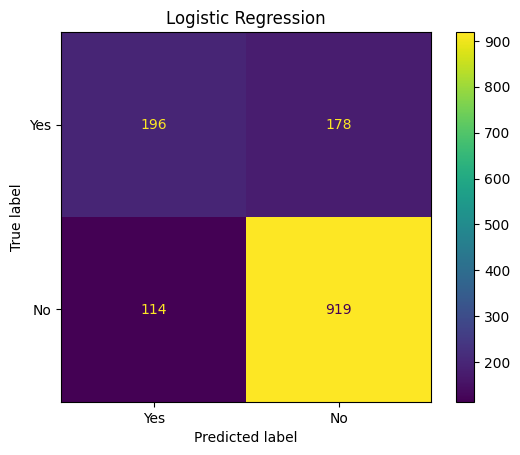

In [9]:
import matplotlib.pyplot as plt

predictions=logistic.predict(X_test)

cm = confusion_matrix(
    y_test,
    predictions,
    labels=["Yes","No"])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Yes","No"]
)

display.plot()

plt.title("Logistic Regression")

plt.show()

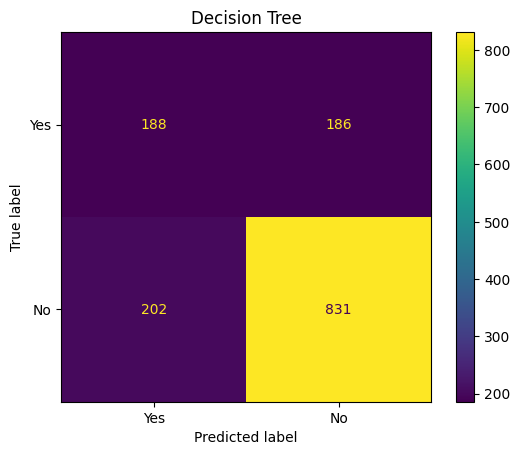

In [10]:
predictions=tree.predict(X_test)

cm = confusion_matrix(
    y_test,
    predictions,
    labels=["Yes","No"])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Yes","No"]
)

display.plot()

plt.title("Decision Tree")

plt.show()

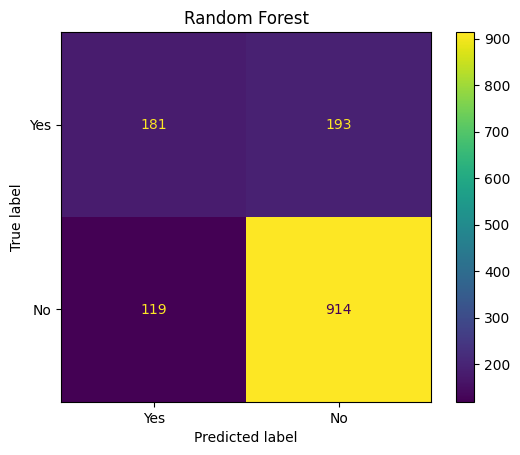

In [11]:
predictions=forest.predict(X_test)

cm = confusion_matrix(
    y_test,
    predictions,
    labels=["Yes","No"])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Yes","No"]
)

display.plot()

plt.title("Random Forest")

plt.show()

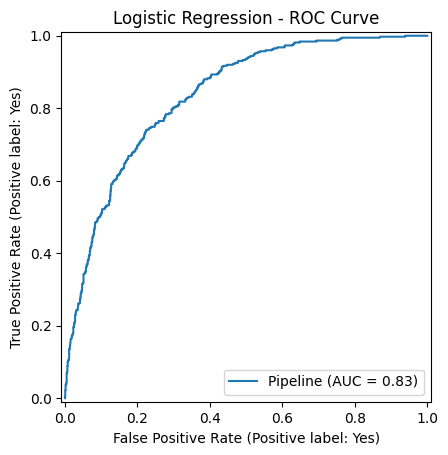

In [12]:
RocCurveDisplay.from_estimator(
    logistic,
    X_test,
    y_test
)

plt.title("Logistic Regression - ROC Curve")

plt.show()

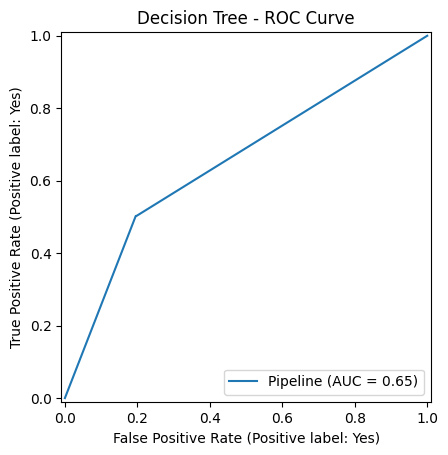

In [13]:
RocCurveDisplay.from_estimator(
    tree,
    X_test,
    y_test
)

plt.title("Decision Tree - ROC Curve")

plt.show()

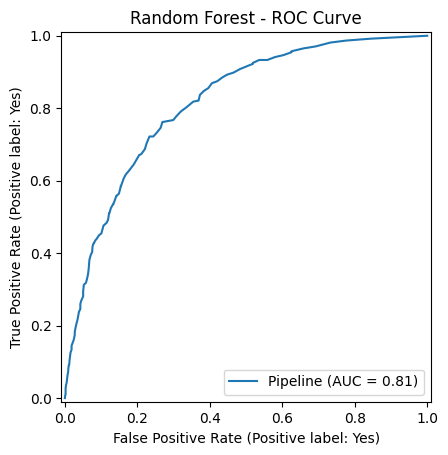

In [14]:
RocCurveDisplay.from_estimator(
    forest,
    X_test,
    y_test
)

plt.title("Random Forest - ROC Curve")

plt.show()

In [15]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

          No       0.83      0.88      0.85      1033
         Yes       0.60      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



I trained Logistic Regression, Decision Tree and Random Forest. Logistic Regression consistently achieved the best overall performance on the test set. It had the highest accuracy (79.25%), precision (63.2%), recall (52.4%), F1-score (57.3%), and ROC-AUC (0.835).